In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("cleaned_combined.csv")
df

,Carrier Code,destination_code,Scheduled elapsed time (Minutes),Actual elapsed time (Minutes),Departure delay (Minutes),Taxi-Out time (Minutes),origin_code,month,day_of_week,scheduled_hour,...,dest_PRCP,dest_SNDP,dest_SLP,dest_ELEVATION,dest_Fog,dest_Rain,dest_Snow,dest_Hail,dest_Thunder,dest_Tornado
0,1,47,110.0,92.0,12.0,12.0,53,1.0,0.0,13.0,...,0.02,0.0,1020.3,191.9,0.0,1.0,1.0,0.0,0.0,0.0
1,1,159,325.0,291.0,-5.0,23.0,53,1.0,0.0,7.0,...,0.00,0.0,1023.3,1288.4,0.0,0.0,0.0,0.0,0.0,0.0
2,1,117,184.0,152.0,-10.0,13.0,53,1.0,0.0,12.0,...,0.02,1.2,1026.8,254.5,0.0,0.0,0.0,0.0,0.0,0.0
3,1,117,194.0,161.0,4.0,20.0,53,1.0,0.0,18.0,...,0.02,1.2,1026.8,254.5,0.0,0.0,0.0,0.0,0.0,0.0
4,1,159,330.0,278.0,18.0,17.0,53,1.0,0.0,18.0,...,0.00,0.0,1023.3,1288.4,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3966857,2,42,105.0,110.0,-6.0,27.0,81,12.0,6.0,9.0,...,0.00,0.0,1011.1,1647.2,0.0,0.0,0.0,0.0,0.0,0.0
3966858,2,127,120.0,101.0,161.0,9.0,81,12.0,0.0,7.0,...,0.47,0.0,1007.0,204.8,0.0,0.0,0.0,0.0,0.0,0.0
3966859,2,42,105.0,152.0,-2.0,71.0,81,12.0,0.0,9.0,...,0.00,0.0,1005.0,1647.2,0.0,0.0,0.0,0.0,0.0,0.0
3966860,2,127,120.0,128.0,-2.0,15.0,81,12.0,1.0,7.0,...,0.23,0.0,1005.7,204.8,0.0,1.0,0.0,0.0,0.0,0.0


In [13]:
delayed_df=df[df['Departure delay (Minutes)'] > 0]

# EDA 

In [55]:
print(df.shape)
print(df.info())
print(df.describe())

(3966862, 43)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3966862 entries, 0 to 3966861
Data columns (total 43 columns):
 #   Column                            Dtype  
---  ------                            -----  
 0   Carrier Code                      int64  
 1   destination_code                  int64  
 2   Scheduled elapsed time (Minutes)  float64
 3   Actual elapsed time (Minutes)     float64
 4   Departure delay (Minutes)         float64
 5   Taxi-Out time (Minutes)           float64
 6   origin_code                       int64  
 7   month                             float64
 8   day_of_week                       float64
 9   scheduled_hour                    float64
 10  weather_delayed                   int64  
 11  origin_TEMP                       float64
 12  origin_DEWP                       float64
 13  origin_VISIB                      float64
 14  origin_WDSP                       float64
 15  origin_MXSPD                      float64
 16  origin_GUST           

# Heatmaps and Correlations

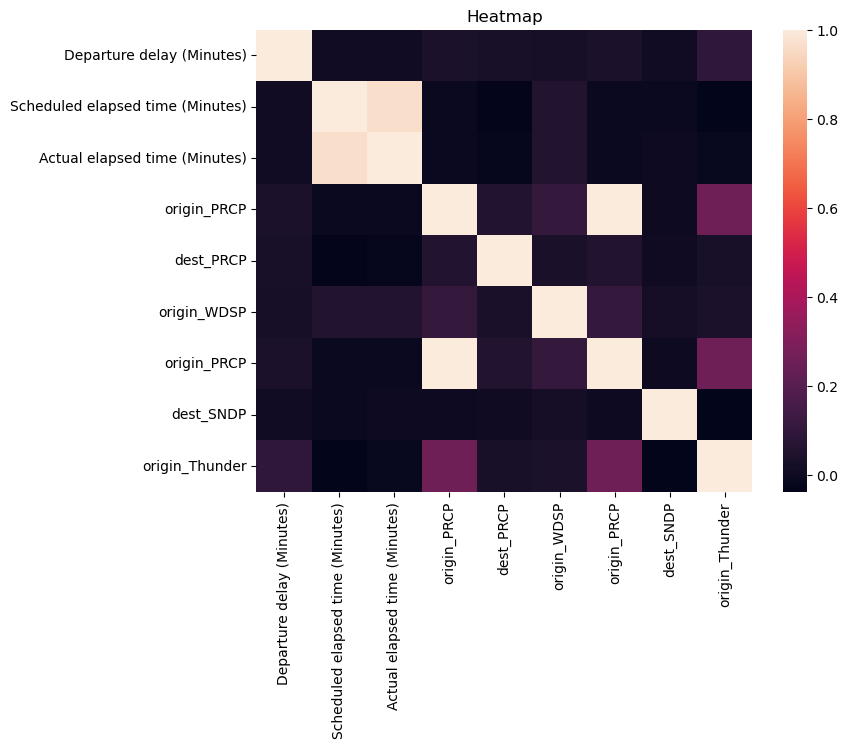

In [25]:
# testing out a heatmap with some variables

cols = ['Departure delay (Minutes)', 'Scheduled elapsed time (Minutes)', 'Actual elapsed time (Minutes)',
        'origin_PRCP', 'dest_PRCP', 'origin_WDSP', 'origin_PRCP', 'dest_SNDP', 'origin_Thunder']
df_heatmap = delayed_df[cols]

# 3. Generate and display the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(data=df_heatmap.corr())
plt.title('Heatmap')
plt.show()

# Pretty weak correlations with chosen features

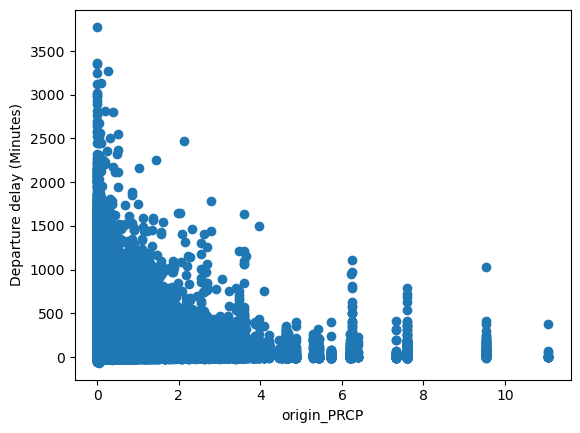

In [32]:
# testing average precipitation and departure delay minutes
plt.scatter(df['origin_PRCP'], df['Departure delay (Minutes)'])

plt.xlabel("origin_PRCP")
plt.ylabel("Departure delay (Minutes)")

plt.show()


In [33]:
from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(df['origin_PRCP'], df['Departure delay (Minutes)'])
r_squared = r_value**2
r_squared

# small r^2 value, meaning no correlation
# similar for df (all flights) and delayed_df (only delays)

np.float64(0.001888471123555397)

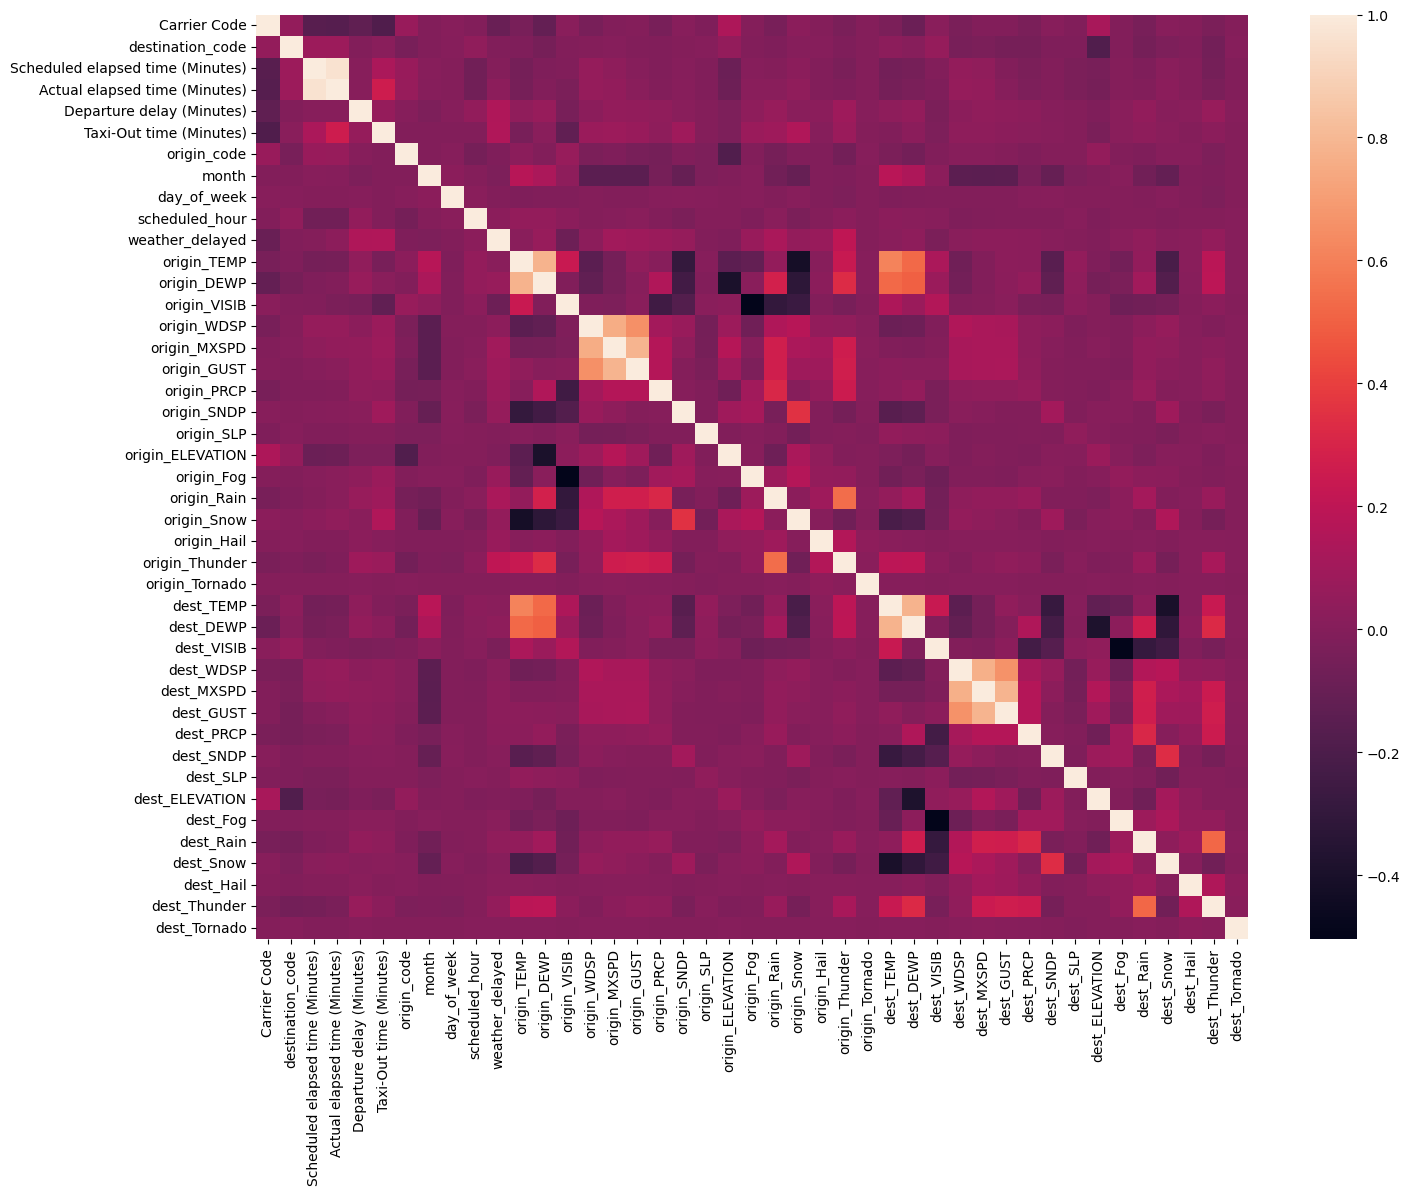

In [19]:
plt.figure(figsize=(16, 12))
sns.heatmap(data=delayed_df.corr())
plt.show()

# not super helpful, most correlations are between the weather data items themselves, not delay in minutes

In [20]:
numeric_df = delayed_df.select_dtypes(include=np.number)
corr = numeric_df.corr()['Departure delay (Minutes)'].sort_values(ascending=False)
print(corr)

# weak correlations between variables and delay in minutes

Departure delay (Minutes)           1.000000
weather_delayed                     0.143397
origin_Thunder                      0.089026
origin_Rain                         0.065804
origin_DEWP                         0.063198
dest_Thunder                        0.062713
Taxi-Out time (Minutes)             0.056384
origin_MXSPD                        0.050399
dest_DEWP                           0.050021
dest_Rain                           0.048448
scheduled_hour                      0.047431
origin_GUST                         0.046281
origin_PRCP                         0.039273
dest_MXSPD                          0.038897
origin_TEMP                         0.037438
dest_GUST                           0.034272
dest_TEMP                           0.032861
origin_Fog                          0.031538
dest_PRCP                           0.029136
origin_Hail                         0.024884
dest_WDSP                           0.024286
origin_WDSP                         0.023792
dest_Fog  

In [23]:
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()['weather_delayed'].sort_values(ascending=False)
print(corr)

# weak correlations between variables and weather delayed or not - origin thunder has the most correlation

weather_delayed                     1.000000
Departure delay (Minutes)           0.178656
origin_Thunder                      0.152661
Taxi-Out time (Minutes)             0.116702
origin_Rain                         0.091993
origin_MXSPD                        0.068812
origin_GUST                         0.063102
origin_PRCP                         0.057396
origin_Hail                         0.052987
origin_DEWP                         0.048142
origin_Fog                          0.046994
dest_Thunder                        0.040700
origin_SNDP                         0.040146
scheduled_hour                      0.038775
origin_Snow                         0.036553
dest_Rain                           0.031010
dest_DEWP                           0.027808
dest_MXSPD                          0.023276
origin_WDSP                         0.022369
Actual elapsed time (Minutes)       0.021066
dest_GUST                           0.020979
dest_PRCP                           0.017714
origin_TEM

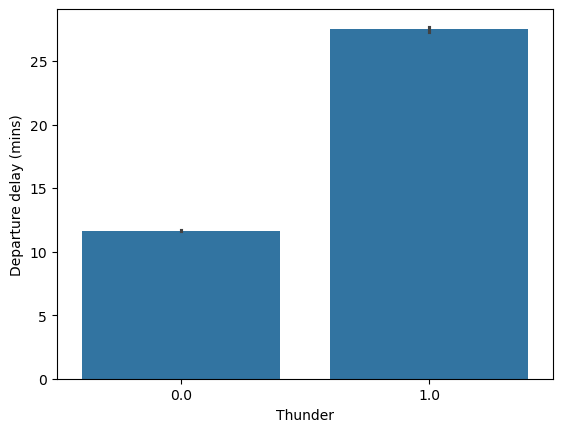

In [27]:

sns.barplot(df, x='origin_Thunder', y='Departure delay (Minutes)')

plt.xlabel("Thunder")
plt.ylabel("Departure delay (mins)")

plt.show()

# increased delay with thunder

# Looking at Airlines, Airports, Months

## Airlines

<Axes: xlabel='Carrier Code', ylabel='Departure delay (Minutes)'>

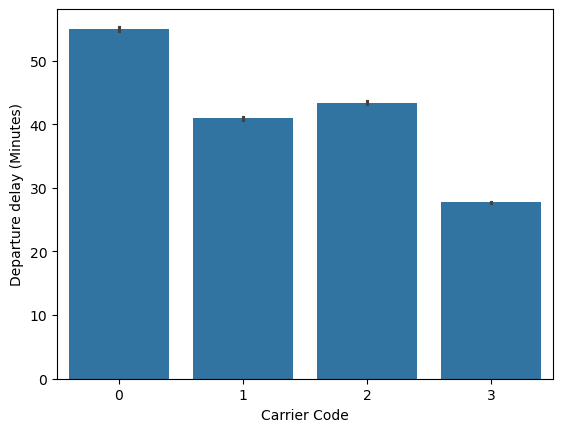

In [7]:
sns.barplot(delayed_df, x='Carrier Code', y='Departure delay (Minutes)')

# Carrier mapping: {0: 'AA', 1: 'DL', 2: 'UA', 3: 'WN'}
# American Airlines has an average delay in minutes that is longer than the rest of the airlines

In [46]:
number_delays = df.groupby(['Carrier Code'])['weather_delayed'].mean().reset_index()
number_delays

# Carrier mapping: {0: 'AA', 1: 'DL', 2: 'UA', 3: 'WN'}
# American Airlines has highest pecentage of weather-delayed flights; Southwest Airlines has lowest
# could be due to travel routes though

,Carrier Code,weather_delayed
0,0,0.020623
1,1,0.007738
2,2,0.009225
3,3,0.004828


## Airports

In [8]:
average_delay_per_airport = delayed_df.groupby(['origin_code'])['Departure delay (Minutes)'].mean().reset_index()
average_delay_per_airport.sort_values(by='Departure delay (Minutes)', ascending=False)

# Longest weather delays on average (when only looking at delayed flight times) 
# 87 - 'ITO' Hilo International Airport in Hawaii
# 14 - 'BIL' Billings-Logan International Airport in Montana
# 96 - 'LEX' Blue Grass Airport - Lexington, Kentucky

# Least
#105 - 'MDW' Chicago Midway International Airport
# 98 - 'LGB' Long Beach Airport (CA)
# 122 - 'OAK' Oakland San Francisco Bay Airport

,origin_code,Departure delay (Minutes)
42,87,81.710292
7,14,74.313084
47,96,64.049566
26,46,60.167844
93,174,59.806889
...,...,...
15,25,28.710662
83,157,28.250975
52,105,27.977306
49,98,25.967991


In [36]:
if_delayed = df.groupby(['origin_code'])['weather_delayed'].mean().reset_index()
if_delayed.sort_values(by='weather_delayed', ascending=False)

# flights rarely ever weather-delayed in the scheme of things

,origin_code,weather_delayed
25,43,0.029972
18,33,0.027945
54,110,0.026153
51,103,0.022272
42,87,0.020947
...,...,...
85,160,0.001703
59,122,0.001276
83,157,0.000813
60,123,0.000277


In [38]:
# flights are only delayed roughly 1% of the time -- going to be unbalanced when training ML
delayed = df['weather_delayed'].mean()
delayed 

np.float64(0.010031606846923337)

## Months

In [12]:
month_and_delays = delayed_df.groupby(['month'])['Departure delay (Minutes)'].mean().reset_index()
month_and_delays.sort_values(by='Departure delay (Minutes)', ascending=False)

# July, May, and August have the highest average weather delays which is a little surprising. 

,month,Departure delay (Minutes)
6,7.0,51.785126
4,5.0,46.256143
7,8.0,42.635018
5,6.0,42.141761
0,1.0,40.871130
2,3.0,38.868736
3,4.0,36.379388
11,12.0,36.326002
1,2.0,31.328828
8,9.0,30.746075


# Key Takeaways

- only roughly 1% of flights are delayed in the dataset -- could make for unbalanced data when doing ML classifier
- no one weather pattern correlated with flight delays
- American Airlines had longest delays in minutes and most weather-delayed flights (could be due to travel routes)